#### Screen the training data set for the code structure

I have approx 600 labeled snippets from approx 150 different news articles coded by Xioaron 

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

fname = "data_snippets_n=154.xlsx" # needs to be updated
training = pd.read_excel(fname)
training = training[['Text', 'Document', 'Codes', 'Number of Codes']]
training.head(2)

,Text,Document,Codes,Number of Codes
0,officials in Indonesia apparently want to make...,urn:contentItem:5B82-9KB1-JDJN-625Y-00000-00.txt,Actor categories: Government 1A: central gover...,1
1,But many Indonesian politicians charge that mi...,urn:contentItem:5B82-9KB1-JDJN-625Y-00000-00.txt,Actor categories: Government 1A: central gover...,3


Category distribution (relative %):
           category        pct
0  Actor categories  35.666667
1    Conflict types  27.750000
2    Character Role  26.916667
3      Policy Tools   5.083333
4      Overall tone   4.583333

Top codes per category (relative % within category):
            category                                               code  \
4   Actor categories       Government 1A: central government/presindent   
1   Actor categories                              Chinese firms/SOEs 2A   
11  Actor categories                       Local community & workers 3A   
3   Actor categories                                  Chinese worker 2D   
2   Actor categories                              Chinese government 2C   
5   Actor categories  Government 1B: local government (provincial/re...   
8   Actor categories   International companies & foreign investments 4B   
9   Actor categories                        International government 4C   
6   Actor categories           Indonesian compani

C:\Users\charlott\AppData\Local\Temp\ipykernel_24664\2933411731.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=category_freq, x='pct', y='category', palette='viridis')


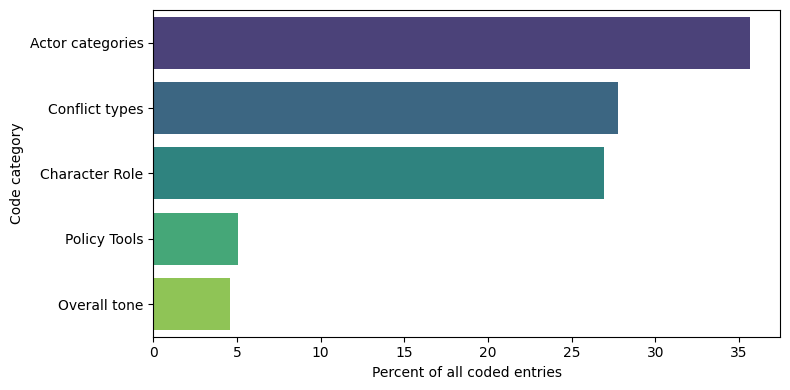

C:\Users\charlott\AppData\Local\Temp\ipykernel_24664\2933411731.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


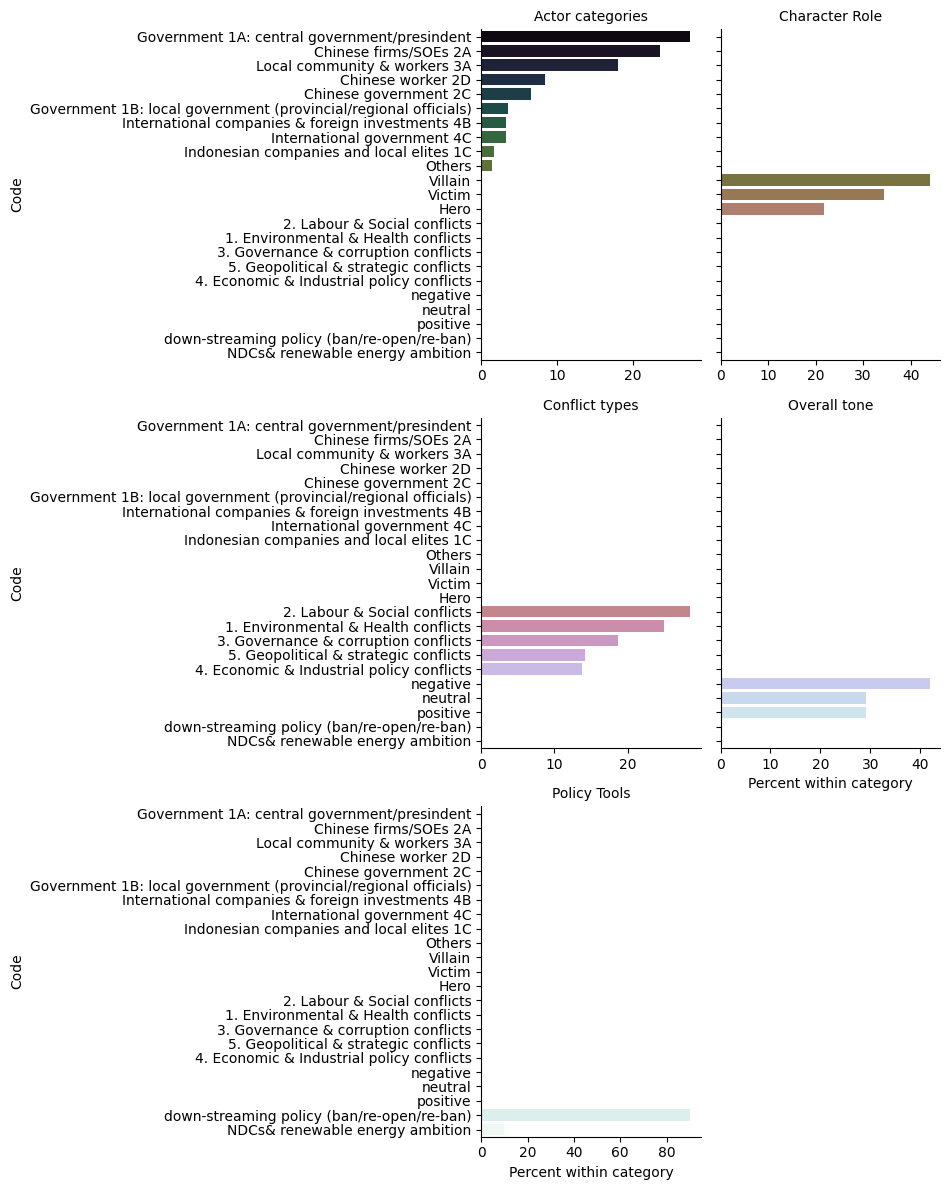

In [7]:
# parse the Codes field into category + code rows
codes_series = training['Codes'].dropna()
rows = []
for cell in codes_series:
    for part in str(cell).split(','):
        code_str = part.strip()
        if not code_str:
            continue
        if ':' in code_str:
            cat_code = code_str.split(':', 1)
            category = cat_code[0].strip()
            code_label = cat_code[1].strip()
        elif '\u2013' in code_str:
            # "Villain – X" entries: already covered by "Character Role: Villain" in the same row, skip
            continue
        else:
            category = 'Unknown'
            code_label = code_str
        rows.append({'category': category, 'code': code_label})

codes_df = pd.DataFrame(rows)

# relative frequency by category
category_freq = codes_df['category'].value_counts(normalize=True).mul(100).reset_index()
category_freq.columns = ['category', 'pct']

# relative frequency by code within each category
code_freq = (
    codes_df
    .groupby(['category', 'code'])
    .size()
    .reset_index(name='count')
)
code_freq['pct_within_category'] = code_freq.groupby('category')['count'].transform(lambda x: x / x.sum() * 100)

# top codes per category (top 10 for plotting clarity)
top_codes = (
    code_freq
    .sort_values(['category', 'count'], ascending=[True, False])
    .groupby('category')
    .head(10)
)

# quick inspection
print("Category distribution (relative %):")
print(category_freq)
print("\nTop codes per category (relative % within category):")
print(top_codes)

# visualization
plt.figure(figsize=(8, 4))
sns.barplot(data=category_freq, x='pct', y='category', palette='viridis')
plt.xlabel('Percent of all coded entries')
plt.ylabel('Code category')
plt.tight_layout()
plt.show()

# per-category code frequency (top 10 each)
g = sns.catplot(
    data=top_codes,
    x='pct_within_category',
    y='code',
    col='category',
    kind='bar',
    col_wrap=2,
    sharex=False,
    height=4,
    aspect=1.2,
    palette='cubehelix'
)
g.set_titles('{col_name}')
g.set_axis_labels('Percent within category', 'Code')
plt.tight_layout()
plt.show()

## Assessment: which code categories are suitable for ML/LLM training?

Based on 589 labeled snippets. Note: `Villain – X` entries (en dash format) were merged into `Character Role: Villain` as they were fully redundant — every such row already contained `Character Role: Villain`.

### Good to go

| Category | Snippets | Notes |
|---|---|---|
| **Actor categories** | 396 | Strong. Most sub-codes have decent counts, though a few (Local civil society: 3, Chinese DFIs: 4) are too rare to predict reliably — consider merging into broader groups. |
| **Character Role** | 323 | Strong. Hero/Villain/Victim are reasonably balanced (70/142/111). |
| **Conflict types** | 319 | Strong. All 5 sub-types have 46–95 examples — usable even for the rarer ones. |

### Borderline / problematic

| Category | Snippets | Notes |
|---|---|---|
| **Overall tone** | 55 | Too few for reliable ML. 55 snippets split across 3 classes (~16–23 each) is marginal. |
| **Policy Tools** | 61 | Very skewed: 55 are `down-streaming policy`, only 6 are `NDCs & renewable energy`. Effectively a one-class problem. |

### Recommendation

Focus ML/LLM training on **Actor categories**, **Character Role**, and **Conflict types**. Drop or merge rare sub-codes in Actor categories (anything with <10 examples). Skip `Overall tone` and `Policy Tools` unless more labeled examples are added.

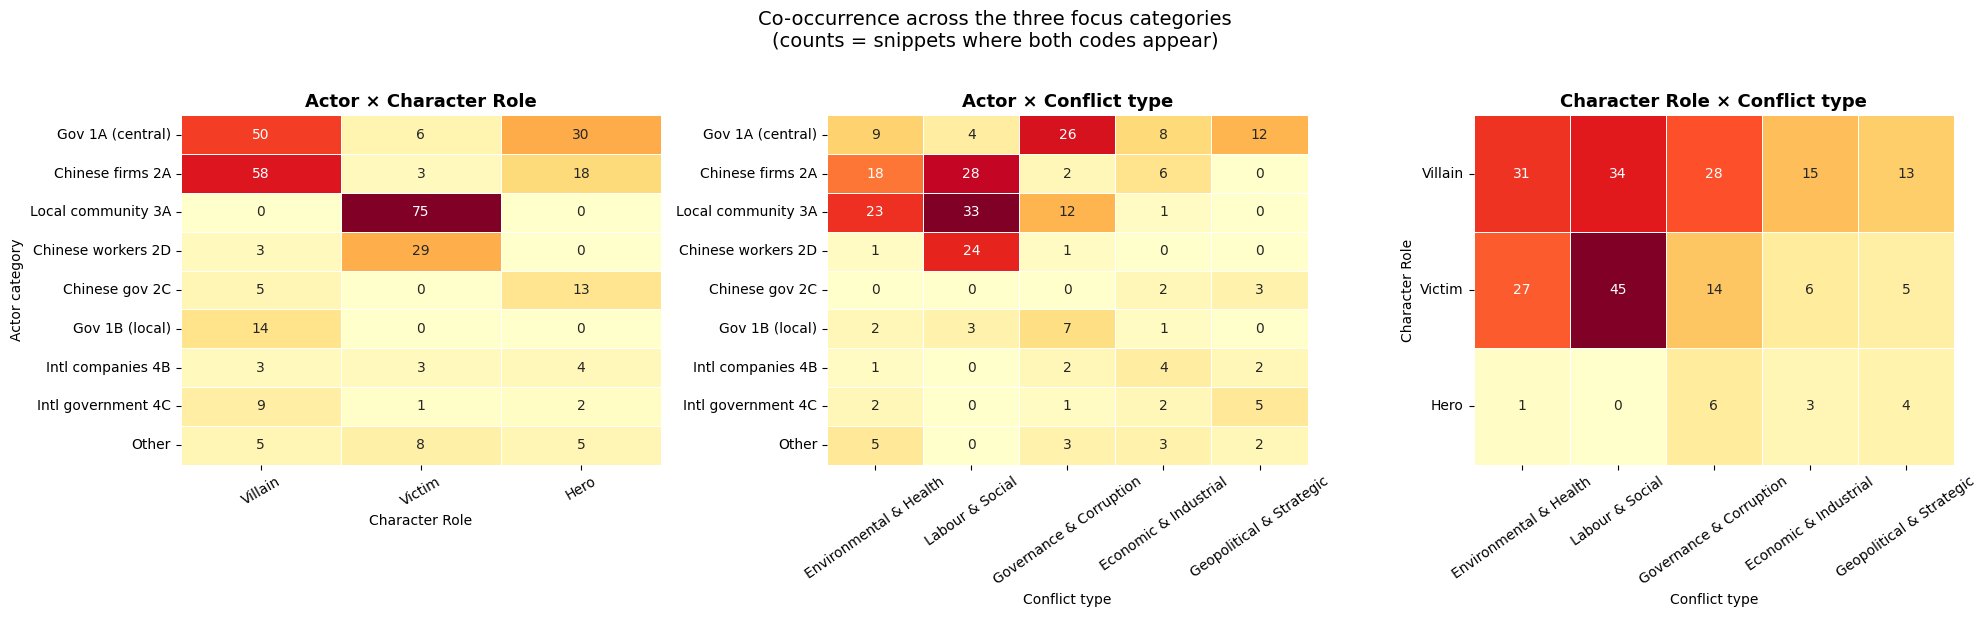

In [8]:
from itertools import product

# --- label shortening ---
actor_rename = {
    'Government 1A: central government/presindent': 'Gov 1A (central)',
    'Chinese firms/SOEs 2A':                        'Chinese firms 2A',
    'Local community & workers 3A':                 'Local community 3A',
    'Chinese worker 2D':                            'Chinese workers 2D',
    'Chinese government 2C':                        'Chinese gov 2C',
    'Government 1B: local government (provincial/regional officials)': 'Gov 1B (local)',
    'International companies & foreign investments 4B': 'Intl companies 4B',
    'International government 4C':                  'Intl government 4C',
}
ACTOR_KEEP = list(actor_rename.values())  # ≥10 examples; rest → "Other"

conflict_rename = {
    '1. Environmental & Health conflicts':      'Environmental & Health',
    '2. Labour & Social conflicts':             'Labour & Social',
    '3. Governance & corruption conflicts':     'Governance & Corruption',
    '4. Economic & Industrial policy conflicts':'Economic & Industrial',
    '5. Geopolitical & strategic conflicts':    'Geopolitical & Strategic',
}

focus = {'Actor categories', 'Character Role', 'Conflict types'}

def parse_snippet(cell):
    out = {'Actor categories': [], 'Character Role': [], 'Conflict types': []}
    for part in str(cell).split(','):
        code_str = part.strip()
        if not code_str or '\u2013' in code_str:
            continue
        if ':' in code_str:
            cat, label = code_str.split(':', 1)
            cat, label = cat.strip(), label.strip()
            if cat == 'Actor categories':
                label = actor_rename.get(label, 'Other')
                out['Actor categories'].append(label)
            elif cat == 'Character Role':
                out['Character Role'].append(label)
            elif cat == 'Conflict types':
                label = conflict_rename.get(label, label)
                out['Conflict types'].append(label)
    return out

snippets = [parse_snippet(c) for c in training['Codes'].dropna()]

ACTORS    = ACTOR_KEEP + ['Other']
ROLES     = ['Villain', 'Victim', 'Hero']
CONFLICTS = list(conflict_rename.values())

def cooccurrence(snippets, cat_a, labels_a, cat_b, labels_b):
    mat = pd.DataFrame(0, index=labels_a, columns=labels_b)
    for s in snippets:
        for a, b in product(set(s[cat_a]), set(s[cat_b])):
            if a in mat.index and b in mat.columns:
                mat.loc[a, b] += 1
    return mat

mat_ar = cooccurrence(snippets, 'Actor categories', ACTORS,    'Character Role', ROLES)
mat_ac = cooccurrence(snippets, 'Actor categories', ACTORS,    'Conflict types', CONFLICTS)
mat_rc = cooccurrence(snippets, 'Character Role',   ROLES,     'Conflict types', CONFLICTS)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

kw = dict(annot=True, fmt='d', linewidths=0.5, cbar=False)

sns.heatmap(mat_ar, ax=axes[0], cmap='YlOrRd', **kw)
axes[0].set_title('Actor × Character Role', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Character Role')
axes[0].set_ylabel('Actor category')
axes[0].tick_params(axis='x', rotation=30)
axes[0].tick_params(axis='y', rotation=0)

sns.heatmap(mat_ac, ax=axes[1], cmap='YlOrRd', **kw)
axes[1].set_title('Actor × Conflict type', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Conflict type')
axes[1].set_ylabel('')
axes[1].tick_params(axis='x', rotation=35)
axes[1].tick_params(axis='y', rotation=0)

sns.heatmap(mat_rc, ax=axes[2], cmap='YlOrRd', **kw)
axes[2].set_title('Character Role × Conflict type', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Conflict type')
axes[2].set_ylabel('Character Role')
axes[2].tick_params(axis='x', rotation=35)
axes[2].tick_params(axis='y', rotation=0)

plt.suptitle('Co-occurrence across the three focus categories\n(counts = snippets where both codes appear)',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Key findings from co-occurrence heatmaps

### Actor × Character Role
The strongest patterns are:
- **Chinese firms (2A) → Villain** (58): Chinese firms are overwhelmingly cast as the villain — the single strongest cell in this heatmap.
- **Local community & workers (3A) → Victim** (75): The local community is almost exclusively portrayed as victims, with zero appearances as Villain or Hero. This is the most clearcut role assignment in the dataset.
- **Central government (1A) → Villain** (50): Central government is also strongly cast as villain, though with some Hero appearances (30), suggesting a more ambivalent portrayal than Chinese firms.
- **Chinese workers (2D) → Victim** (29): Chinese workers follow a similar victim pattern to the local community, though less dominant.

### Actor × Conflict type
The strongest patterns are:
- **Local community (3A) × Labour & Social** (33) and **× Environmental & Health** (23): Local community appears most frequently in labour/social and environmental conflicts — consistent with their victim role.
- **Chinese firms (2A) × Labour & Social** (28) and **× Environmental & Health** (18): Chinese firms dominate in these same two conflict types, making sense given they are the villain counterpart to the local community victims.
- **Chinese workers (2D) × Labour & Social** (24): Chinese workers are almost exclusively associated with labour conflicts.
- **Central government (1A) × Governance & Corruption** (26): The central government's strongest conflict association is governance and corruption — distinct from Chinese firms.

### Character Role × Conflict type
- **Victim × Labour & Social** (45) and **Villain × Labour & Social** (34): Labour & Social conflicts produce the most intense victim–villain dynamic in the dataset.
- **Victim × Environmental & Health** (27) and **Villain × Environmental & Health** (31): Environmental conflicts follow a similar but slightly less intense pattern.
- **Hero** is sparse across all conflict types, with the highest values in Governance & Corruption (6), Geopolitical (4), and Economic & Industrial (3) — suggesting heroes emerge mainly in political/institutional rather than grassroots conflict narratives.

=== Word count summary ===
count    610.0
mean      55.9
std       32.6
min        3.0
25%       33.0
50%       53.0
75%       73.0
max      273.0
Name: Text, dtype: float64

Median: 53 words
<= 30 words :  124 snippets
31–100 words:  436 snippets
> 100 words :   50 snippets


C:\Users\charlott\AppData\Local\Temp\ipykernel_24664\675824053.py:39: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[2].boxplot(


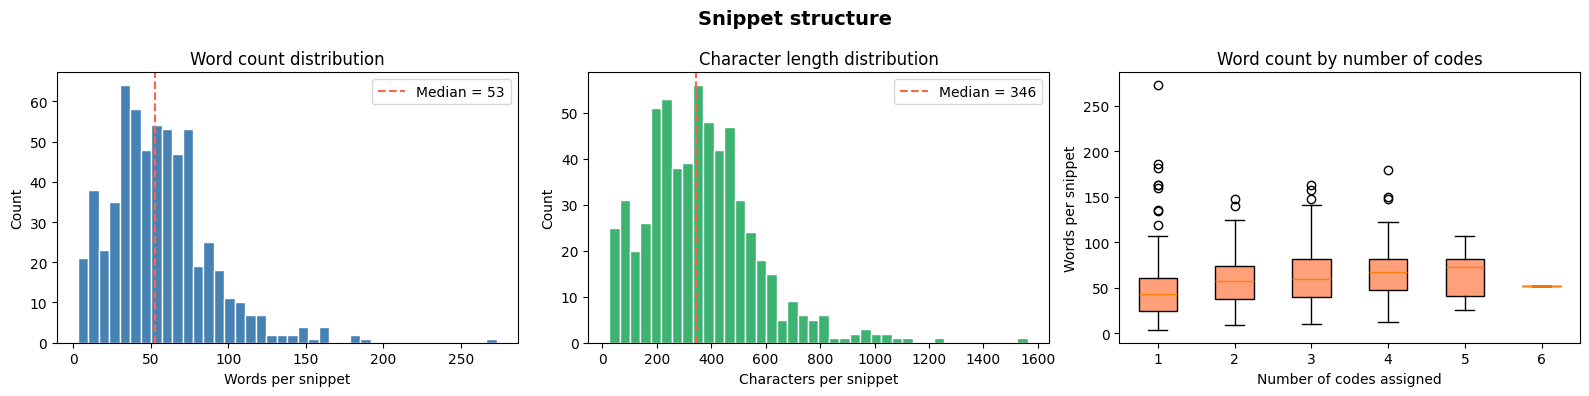

In [12]:
# ── Snippet structure analysis ──────────────────────────────────────────────
texts = training['Text'].dropna()

lengths_chars = texts.str.len()
lengths_words = texts.str.split().str.len()

# summary stats
print("=== Word count summary ===")
print(lengths_words.describe().round(1))
print(f"\nMedian: {lengths_words.median():.0f} words")
print(f"<= 30 words : {(lengths_words <= 30).sum():>4d} snippets")
print(f"31–100 words: {((lengths_words > 30) & (lengths_words <= 100)).sum():>4d} snippets")
print(f"> 100 words : {(lengths_words > 100).sum():>4d} snippets")

# ── plots ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1. word count distribution
axes[0].hist(lengths_words, bins=40, color='steelblue', edgecolor='white')
axes[0].axvline(lengths_words.median(), color='tomato', linestyle='--', label=f'Median = {lengths_words.median():.0f}')
axes[0].set_title('Word count distribution')
axes[0].set_xlabel('Words per snippet')
axes[0].set_ylabel('Count')
axes[0].legend()

# 2. character length distribution
axes[1].hist(lengths_chars, bins=40, color='mediumseagreen', edgecolor='white')
axes[1].axvline(lengths_chars.median(), color='tomato', linestyle='--', label=f'Median = {lengths_chars.median():.0f}')
axes[1].set_title('Character length distribution')
axes[1].set_xlabel('Characters per snippet')
axes[1].set_ylabel('Count')
axes[1].legend()

# 3. word count by number of codes assigned
labeled = training.dropna(subset=['Codes']).copy()
labeled['word_count'] = labeled['Text'].str.split().str.len()
labeled['Number of Codes'] = labeled['Number of Codes'].astype(int)

axes[2].boxplot(
    [labeled.loc[labeled['Number of Codes'] == n, 'word_count'].dropna()
     for n in sorted(labeled['Number of Codes'].unique())],
    labels=sorted(labeled['Number of Codes'].unique()),
    patch_artist=True,
    boxprops=dict(facecolor='lightsalmon')
)
axes[2].set_title('Word count by number of codes')
axes[2].set_xlabel('Number of codes assigned')
axes[2].set_ylabel('Words per snippet')

plt.suptitle('Snippet structure', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 1 — Build the labeled training matrix (Conflict types only)

Actor categories will be handled separately via NER. Character Role is set aside for now. We focus exclusively on the **5 Conflict type** classes, all of which have sufficient labeled examples (46–95 per class, no merging needed).

Each row = one snippet from `training` that has at least one conflict label. Binary indicator columns `conflict__X` are created for each of the 5 classes. Snippets with no conflict label are dropped.

In [15]:
CONFLICT_LABELS = list(conflict_rename.values())

def extract_conflicts(cell):
    conflicts = set()
    if pd.isna(cell):
        return conflicts
    for part in str(cell).split(','):
        code_str = part.strip()
        if not code_str or '\u2013' in code_str:
            continue
        if ':' in code_str:
            cat, label = code_str.split(':', 1)
            cat, label = cat.strip(), label.strip()
            if cat == 'Conflict types':
                conflicts.add(conflict_rename.get(label, label))
    return conflicts

rows = []
for _, row in training.iterrows():
    conflicts = extract_conflicts(row['Codes'])
    if not conflicts:
        continue   # no conflict label — not part of training set
    record = {
        'snippet'    : row['Text'],
        'article_id' : row['Document'],
    }
    for c in CONFLICT_LABELS:
        record[f'conflict__{c}'] = int(c in conflicts)
    rows.append(record)

train_df = pd.DataFrame(rows)

print(f"Total rows in training file        : {len(training)}")
print(f"Rows with conflict labels (kept)   : {len(train_df)}")
print(f"Rows dropped (no conflict label)   : {len(training) - len(train_df)}")
print(f"\nLabel distribution (positive examples per conflict class):")
conflict_cols = [f'conflict__{c}' for c in CONFLICT_LABELS]
print(train_df[conflict_cols].sum().sort_values(ascending=False).to_string())
print(f"\nSnippets with multiple conflict labels: {(train_df[conflict_cols].sum(axis=1) > 1).sum()}")
print(f"Snippets with exactly one label       : {(train_df[conflict_cols].sum(axis=1) == 1).sum()}")

train_df.head(3)

Total rows in training file        : 610
Rows with conflict labels (kept)   : 319
Rows dropped (no conflict label)   : 291

Label distribution (positive examples per conflict class):
conflict__Labour & Social             95
conflict__Environmental & Health      83
conflict__Governance & Corruption     62
conflict__Geopolitical & Strategic    47
conflict__Economic & Industrial       46

Snippets with multiple conflict labels: 13
Snippets with exactly one label       : 306


,snippet,article_id,conflict__Environmental & Health,conflict__Labour & Social,conflict__Governance & Corruption,conflict__Economic & Industrial,conflict__Geopolitical & Strategic
0,But many Indonesian politicians charge that mi...,urn:contentItem:5B82-9KB1-JDJN-625Y-00000-00.txt,0,0,0,1,0
1,The Indonesian government introduced regulator...,urn:contentItem:5MMD-2Y81-F03R-N4JN-00000-00.txt,0,0,0,1,0
2,A funding crunch is also starting to raise con...,urn:contentItem:5W41-RJS1-JCNX-33SS-00000-00.txt,0,0,0,1,0


## Splitting full articles into snippets

### What we are doing
We have 2,700 full newspaper articles that we want to classify using the three focus categories identified above (Actor categories, Character Role, Conflict types). To do this, we need to break each article into short text units — snippets — that can be passed to the classifier one at a time.

We use a **sentence-grouped sliding window** approach:
- Sentences are grouped together until a target word count is reached (60–80 words)
- The window then advances by one sentence at a time (one-sentence overlap between consecutive windows)
- Snippets shorter than 20 words are discarded as uninformative fragments

### Why this approach
Our labeled training data consists of snippets manually selected by human coders. The structural analysis above shows that the vast majority of these fall between 30 and 100 words, with a median of 53 words. The sentence-grouped sliding window is the closest mechanical approximation to this process: it preserves sentence boundaries (so no clause is cut mid-way), and the one-sentence overlap ensures that content spanning two consecutive windows is not missed.

Fixed-word windows were rejected because they cut sentences arbitrarily, degrading the linguistic cues (actor mentions, role attributions, conflict framings) that the classifier relies on. Paragraph-based splits were rejected because newspaper paragraphs vary too widely in length and often fall outside the 30–100 word range of the training data.

### What to expect
Most snippets produced by this mechanical split will not contain codeable content — they cover background information, transitions, or context unrelated to the conflict framing categories. This is normal. The classifier will learn to output no label for these snippets. Optionally, a binary relevance filter can be applied first to reduce noise before multi-label classification.

In [16]:
LN_PATH = r"C:\Users\charlott\Dropbox (Personal)\Paper_Indonesia_Nickel\ln_preprocessing\ln_data_final.csv"

ln_full = pd.read_csv(LN_PATH)
print(f"Total articles in ln_data_final   : {ln_full['ID'].nunique()}")

# ── get training article IDs ─────────────────────────────────────────────────
# training 'Document' column has a .txt suffix: strip it to match
training_ids = set(
    training['Document'].dropna()
    .str.replace(r'\.txt$', '', regex=True)
    .unique()
)
print(f"Unique articles in training set   : {len(training_ids)}")

# ── exclude training articles ────────────────────────────────────────────────
ln_inference = ln_full[~ln_full['ID'].isin(training_ids)].reset_index(drop=True)

print(f"Articles excluded (in training)   : {len(ln_full) - len(ln_inference)}")
print(f"Distinct IDs remaining            : {ln_inference['ID'].nunique()}")
ln_inference.head(3)

Total articles in ln_data_final   : 2334
Unique articles in training set   : 153
Articles excluded (in training)   : 153
Distinct IDs remaining            : 2181


,ID,Title,WordLength,Byline,Outlet_Name,Date,Indonesia_Mentions,China_Mentions,Nickel_Mentions,Text_body
0,urn:contentItem:6313-C6K1-DY4H-K3FJ-00000-00,Mining holds the key to a green future - no wo...,1106,Kevin Watkins,"The Guardian (London), BUSINESS; Version:2, 11...",2021-06-27,3,4,3,Mining holds the key to a green future - no wo...
1,urn:contentItem:60NV-6JH1-JBK6-S006-00000-00,Elon Musk Is Going to Have a Hard Time Finding...,882,Bloomberg,"Caixin Global, WORLD, 882words",2020-08-25,6,4,21,Elon Musk Is Going to Have a Hard Time Finding...
2,urn:contentItem:5YYB-XBF1-DYTM-93D3-00000-00,The Green New Deal and global justice.,4877,"Paul, Harpreet Kaur","Renewal ASAP, Pg. 61; ISSN: 0968-252X; Vol. 28...",2020-03-22,2,2,1,The Green New Deal and global justice. 2020-03...


In [17]:
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
from nltk.tokenize import sent_tokenize

TARGET_MIN  = 60   # start a new window once we hit this
TARGET_MAX  = 80   # hard cap — if a single sentence exceeds this we keep it anyway
MIN_SNIPPET = 20   # discard fragments shorter than this
OVERLAP     = 1    # sentences carried over into the next window

def sliding_window_snippets(text, target_min=TARGET_MIN, target_max=TARGET_MAX,
                             min_words=MIN_SNIPPET, overlap=OVERLAP):
    sentences = sent_tokenize(str(text))
    snippets = []
    i = 0
    while i < len(sentences):
        window = []
        word_count = 0
        j = i
        while j < len(sentences):
            w = len(sentences[j].split())
            if word_count + w > target_max and window:
                break
            window.append(sentences[j])
            word_count += w
            j += 1
            if word_count >= target_min:
                break
        snippet = ' '.join(window).strip()
        if len(snippet.split()) >= min_words:
            snippets.append(snippet)
        # advance by (window size - overlap), minimum 1
        advance = max(1, len(window) - overlap)
        i += advance
    return snippets

# ── apply to all inference articles ─────────────────────────────────────────
rows = []
for _, article in ln_inference.iterrows():
    for snippet in sliding_window_snippets(article['Text_body']):
        rows.append({
            'article_id'  : article['ID'],
            'title'       : article['Title'],
            'outlet'      : article['Outlet_Name'],
            'date'        : article['Date'],
            'snippet'     : snippet,
            'word_count'  : len(snippet.split()),
        })

snippets_df = pd.DataFrame(rows)

# ── summary ──────────────────────────────────────────────────────────────────
print(f"Articles processed          : {ln_inference['ID'].nunique()}")
print(f"Total snippets generated    : {len(snippets_df)}")
print(f"Avg snippets per article    : {len(snippets_df) / ln_inference['ID'].nunique():.1f}")
print(f"\nSnippet word count:")
print(snippets_df['word_count'].describe().round(1))
print(f"\nSnippets < {MIN_SNIPPET} words (discarded): already excluded")
print(f"Snippets 20–60 words  : {((snippets_df['word_count'] >= 20) & (snippets_df['word_count'] < 60)).sum()}")
print(f"Snippets 60–80 words  : {((snippets_df['word_count'] >= 60) & (snippets_df['word_count'] <= 80)).sum()}")
print(f"Snippets > 80 words   : {(snippets_df['word_count'] > 80).sum()}")

snippets_df.head(3)

Articles processed          : 2181
Total snippets generated    : 83079
Avg snippets per article    : 38.1

Snippet word count:
count    83079.0
mean        65.7
std         31.3
min         20.0
25%         59.0
50%         65.0
75%         72.0
max       2087.0
Name: word_count, dtype: float64

Snippets < 20 words (discarded): already excluded
Snippets 20–60 words  : 21795
Snippets 60–80 words  : 59250
Snippets > 80 words   : 2034


,article_id,title,outlet,date,snippet,word_count
0,urn:contentItem:6313-C6K1-DY4H-K3FJ-00000-00,Mining holds the key to a green future - no wo...,"The Guardian (London), BUSINESS; Version:2, 11...",2021-06-27,Mining holds the key to a green future - no wo...,68
1,urn:contentItem:6313-C6K1-DY4H-K3FJ-00000-00,Mining holds the key to a green future - no wo...,"The Guardian (London), BUSINESS; Version:2, 11...",2021-06-27,"Not any more. Today, the shallow sandbank, loc...",62
2,urn:contentItem:6313-C6K1-DY4H-K3FJ-00000-00,Mining holds the key to a green future - no wo...,"The Guardian (London), BUSINESS; Version:2, 11...",2021-06-27,Welcome to the beginning of the end of the fos...,73


## Snippet split — sanity check

**What to expect:** A typical LexisNexis article in this dataset runs ~500–900 words. With 60–80 word windows and one-sentence overlap, each article should yield roughly 8–15 snippets, putting the total somewhere between 15,000 and 30,000 snippets.

**Distribution check:** The median snippet word count should sit in the 60–80 word range. A long tail above 80 words is normal — it reflects articles with long sentences that exceed the target cap but are kept intact. A secondary bump below 60 words is also expected for article-ending fragments (last sentence(s) of an article that don't fill a full window but pass the 20-word minimum).

**Red flags to watch for:**
- Median well below 50 words → windows are too short; consider raising `TARGET_MIN`
- Very high snippet count (>50 per article on average) → articles may contain boilerplate/repeated text that inflates the count
- Many snippets > 150 words → articles likely contain very long run-on sentences; consider splitting on punctuation as a fallback

In [18]:
print(f"Articles processed         : {ln_inference['ID'].nunique()}")
print(f"Total snippets             : {len(snippets_df)}")
print(f"Avg snippets per article   : {len(snippets_df) / ln_inference['ID'].nunique():.1f}")
print(f"\nWord count distribution:")
print(snippets_df['word_count'].describe().round(1))
print(f"\nSnippets 20–59 words  : {((snippets_df['word_count'] >= 20) & (snippets_df['word_count'] < 60)).sum()}")
print(f"Snippets 60–80 words  : {((snippets_df['word_count'] >= 60) & (snippets_df['word_count'] <= 80)).sum()}")
print(f"Snippets 81–150 words : {((snippets_df['word_count'] > 80) & (snippets_df['word_count'] <= 150)).sum()}")
print(f"Snippets > 150 words  : {(snippets_df['word_count'] > 150).sum()}")

Articles processed         : 2181
Total snippets             : 83079
Avg snippets per article   : 38.1

Word count distribution:
count    83079.0
mean        65.7
std         31.3
min         20.0
25%         59.0
50%         65.0
75%         72.0
max       2087.0
Name: word_count, dtype: float64

Snippets 20–59 words  : 21795
Snippets 60–80 words  : 59250
Snippets 81–150 words : 1377
Snippets > 150 words  : 657


## Snippet split — results

**83,079 snippets** from 2,181 articles. The word count distribution is healthy: median 65 words, and 71% of snippets (59,250) land exactly in the 60–80 word target band.

**Red flag — avg 38 snippets per article** (expected: 8–15). This is well above expectations and likely caused by LexisNexis boilerplate: repeated legal notices, copyright footers, and syndication headers that inflate the article text. A few high-count articles should be inspected to confirm.

**Long tail:** 657 snippets exceed 150 words (max: 2,087). These are single sentences too long to split further — likely tables, bullet lists run together, or garbled OCR text. Small in number but worth filtering before classification.

In [19]:
# top 5 articles by snippet count
top5_ids = (
    snippets_df.groupby('article_id')
    .size()
    .sort_values(ascending=False)
    .head(5)
    .reset_index()
    .rename(columns={0: 'snippet_count'})
)

# join with full article text for manual inspection
top5 = top5_ids.merge(ln_inference[['ID', 'Title', 'Outlet_Name', 'Date', 'Text_body']],
                      left_on='article_id', right_on='ID').drop(columns='ID')

out_path = r"C:\Users\charlott\Dropbox (Personal)\Paper_Indonesia_Nickel\ln_labelling\high_count_articles_inspection.xlsx"
top5.to_excel(out_path, index=False)
print(f"Exported to: {out_path}")
print()
print(top5[['article_id', 'Title', 'snippet_count']].to_string(index=False))

Exported to: C:\Users\charlott\Dropbox (Personal)\Paper_Indonesia_Nickel\ln_labelling\high_count_articles_inspection.xlsx

                                  article_id                                                            Title  snippet_count
urn:contentItem:65GT-TTH1-JB20-G3V0-00000-00         Orbia Advance Corporation SAB de CV Investor Day - Final            721
urn:contentItem:69SF-MF81-JCS1-6427-00000-00                          Acerinox SA Capital Markets Day - Final            714
urn:contentItem:5CMH-CR41-JB4P-V1DB-00000-00 MWANA AFRICA PLC - Audited Results for the Year to 31 March 2014            699
urn:contentItem:69NM-P9W1-JCS1-623S-00000-00           Eramet SA irst Capital Markets Day "A New ERA" - Final            664
urn:contentItem:66HF-7401-F053-D04T-00000-00                       Aperam SA Capital Market Day Day 1 - Final            660


In [20]:
# ── keyword presence per snippet ─────────────────────────────────────────────
keywords = ['china', 'indonesia', 'nickel']

text_lower = snippets_df['snippet'].str.lower()
for kw in keywords:
    snippets_df[kw] = text_lower.str.contains(kw, regex=False).astype(int)

total = len(snippets_df)

# ── co-occurrence matrix ──────────────────────────────────────────────────────
cooc = pd.DataFrame(index=keywords, columns=keywords, dtype=int)
for a in keywords:
    for b in keywords:
        cooc.loc[a, b] = (snippets_df[a] & snippets_df[b]).sum()

cooc = cooc.fillna(0).astype(int)  # ensure integer values, no float in the heatmap input

# individual counts on diagonal are already correct (kw & kw = kw)
print("Co-occurrence counts (snippets containing both):")
print(cooc)
print(f"\nTotal snippets: {total}")
for kw in keywords:
    print(f"  '{kw}' present: {snippets_df[kw].sum()} ({snippets_df[kw].mean()*100:.1f}%)")
    

Co-occurrence counts (snippets containing both):
           china  indonesia  nickel
china      14729       5316    3592
indonesia   5316      17535    6198
nickel      3592       6198   13944

Total snippets: 83079
  'china' present: 14729 (17.7%)
  'indonesia' present: 17535 (21.1%)
  'nickel' present: 13944 (16.8%)


## Fine-tuning: Conflict type classifier

We fine-tune **DistilBERT** (`distilbert-base-uncased`) as a multi-label classifier on the 5 conflict classes. 
DistilBERT is chosen because our training set is small (~319 snippets) — a lighter model reduces overfitting risk.

**Setup:**
- Task: multi-label classification (a snippet can belong to more than one class simultaneously)
- Loss: BCEWithLogitsLoss (binary cross-entropy per label)
- Split: 80% train / 20% validation
- Metric: macro F1 (treats all 5 classes equally)
- Early stopping patience=3, best checkpoint reloaded at end

After training the model is applied to all cleaned snippets in `snippets_df`.

In [21]:
import re

def clean_snippet(text):
    if pd.isna(text): return ''
    text = str(text)
    text = re.sub(r'\s+', ' ', text).strip()
    text = re.sub(r'\b\d{6,}\b', '', text)  # remove long number strings
    return text

train_df['snippet_clean'] = train_df['snippet'].apply(clean_snippet)

# filter inference snippets: drop >150 words (boilerplate / garbled)
snippets_df['snippet_clean'] = snippets_df['snippet'].apply(clean_snippet)
snippets_inf = snippets_df[snippets_df['word_count'] <= 150].reset_index(drop=True)

print(f'Training snippets (with conflict label) : {len(train_df)}')
print(f'Inference snippets before filter        : {len(snippets_df)}')
print(f'Inference snippets after >150w filter   : {len(snippets_inf)}')


Training snippets (with conflict label) : 319
Inference snippets before filter        : 83079
Inference snippets after >150w filter   : 82422


In [22]:
from transformers import (
    DistilBertTokenizerFast, DistilBertForSequenceClassification,
    Trainer, TrainingArguments, EarlyStoppingCallback
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report
import torch
from torch.utils.data import Dataset
import numpy as np

MODEL_NAME    = 'distilbert-base-uncased'
MAX_LEN       = 128
CONFLICT_COLS = [f'conflict__{c}' for c in CONFLICT_LABELS]

tokenizer = DistilBertTokenizerFast.from_pretrained(MODEL_NAME)

class ConflictDataset(Dataset):
    def __init__(self, texts, labels=None):
        self.enc    = tokenizer(texts, truncation=True, padding=True, max_length=MAX_LEN)
        self.labels = labels
    def __len__(self): return len(self.enc['input_ids'])
    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.enc.items()}
        if self.labels is not None:
            item['labels'] = torch.tensor(self.labels[idx], dtype=torch.float)
        return item

# train / val split
X = train_df['snippet_clean'].tolist()
y = train_df[CONFLICT_COLS].values.tolist()
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Train: {len(X_train)}  |  Val: {len(X_val)}')

train_ds = ConflictDataset(X_train, y_train)
val_ds   = ConflictDataset(X_val,   y_val)

model = DistilBertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(CONFLICT_LABELS),
    problem_type='multi_label_classification',
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    probs = 1 / (1 + np.exp(-logits))
    preds = (probs >= 0.5).astype(int)
    return {
        'f1_macro': f1_score(labels, preds, average='macro', zero_division=0),
        'f1_micro': f1_score(labels, preds, average='micro', zero_division=0),
    }

MODEL_DIR = r'C:\Users\charlott\Dropbox (Personal)\Paper_Indonesia_Nickel\ln_labelling\conflict_model'

args = TrainingArguments(
    output_dir                  = MODEL_DIR,
    num_train_epochs            = 15,
    per_device_train_batch_size = 16,
    per_device_eval_batch_size  = 32,
    eval_strategy               = 'epoch',
    save_strategy               = 'epoch',
    load_best_model_at_end      = True,
    metric_for_best_model       = 'f1_macro',
    greater_is_better           = True,
    learning_rate               = 2e-5,
    weight_decay                = 0.01,
    logging_steps               = 10,
    seed                        = 42,
    report_to                   = 'none',
)

trainer = Trainer(
    model           = model,
    args            = args,
    train_dataset   = train_ds,
    eval_dataset    = val_ds,
    compute_metrics = compute_metrics,
    callbacks       = [EarlyStoppingCallback(early_stopping_patience=3)],
)

trainer.train()

# validation report
pred_out  = trainer.predict(val_ds)
probs_val = 1 / (1 + np.exp(-pred_out.predictions))
preds_val = (probs_val >= 0.5).astype(int)
print(classification_report(y_val, preds_val, target_names=CONFLICT_LABELS, zero_division=0))


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

Train: 255  |  Val: 64


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
c:\Users\charlott\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch,Training Loss,Validation Loss,F1 Macro,F1 Micro
1,0.653500,0.534285,0.000000,0.000000
2,0.494200,0.491567,0.000000,0.000000
3,0.469400,0.456005,0.113889,0.138889
4,0.410800,0.409824,0.357088,0.531915
5,0.360600,0.381045,0.365977,0.556701
6,0.322600,0.350451,0.378818,0.568421
7,0.305100,0.330781,0.359048,0.536082
8,0.280200,0.334495,0.354409,0.534653
9,0.240300,0.305194,0.506691,0.603774
10,0.226100,0.302493,0.568755,0.648649


c:\Users\charlott\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\charlott\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\charlott\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\charlott\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be 

                          precision    recall  f1-score   support

  Environmental & Health       0.81      0.87      0.84        15
         Labour & Social       0.93      0.93      0.93        14
 Governance & Corruption       0.86      0.50      0.63        12
   Economic & Industrial       0.83      0.33      0.48        15
Geopolitical & Strategic       0.43      0.27      0.33        11

               micro avg       0.80      0.60      0.68        67
               macro avg       0.77      0.58      0.64        67
            weighted avg       0.79      0.60      0.66        67
             samples avg       0.62      0.62      0.62        67



## Training results — validation performance

**Train: 255 snippets | Val: 64 snippets** (80/20 split)

The model runs on CPU (no GPU found), which is slower but functionally correct.

### Per-class F1 on validation set

| Conflict class | Precision | Recall | F1 | Support |
|---|---|---|---|---|
| Environmental & Health | 0.81 | 0.87 | **0.84** | 15 |
| Labour & Social | 0.93 | 0.93 | **0.93** | 14 |
| Governance & Corruption | 0.86 | 0.50 | **0.63** | 12 |
| Economic & Industrial | 0.83 | 0.33 | **0.48** | 15 |
| Geopolitical & Strategic | 0.43 | 0.27 | **0.33** | 11 |

**Macro F1: 0.64 | Micro F1: 0.68**

### Interpretation

**Strong classes:** Labour & Social (F1=0.93) and Environmental & Health (F1=0.84) perform well — these are the two most frequent classes in training and have the most distinctive vocabulary.

**Weak classes:** Economic & Industrial (F1=0.48) and Geopolitical & Strategic (F1=0.33) struggle. Both suffer from low recall, meaning the model is missing many true positives. Likely causes: (1) fewer training examples (46–47 each), and (2) these conflict types use more abstract, policy-level language that is harder to distinguish from each other and from Governance & Corruption.

**Precision is generally higher than recall** — the model is conservative: when it assigns a label it is usually right, but it misses a substantial share of true cases.

### What to do next
- The two strong classes are reliable enough for downstream analysis.
- For the three weaker classes, consider: (1) adding more labeled examples, (2) augmenting training data, or (3) treating their predictions as probabilistic scores rather than hard labels (using  rather than ).
- The  warnings are harmless — they indicate CPU training only; no action needed.

In [23]:
# inference on all cleaned snippets
BATCH_SIZE = 64
device     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.eval().to(device)

inf_texts = snippets_inf['snippet_clean'].tolist()
all_probs = []

for i in range(0, len(inf_texts), BATCH_SIZE):
    batch = inf_texts[i : i + BATCH_SIZE]
    enc   = tokenizer(batch, truncation=True, padding=True,
                      max_length=MAX_LEN, return_tensors='pt').to(device)
    with torch.no_grad():
        logits = model(**enc).logits
    all_probs.append(torch.sigmoid(logits).cpu().numpy())
    if i % 5000 == 0:
        print(f'  processed {i}/{len(inf_texts)}')

all_probs = np.vstack(all_probs)
all_preds = (all_probs >= 0.5).astype(int)

for j, c in enumerate(CONFLICT_LABELS):
    snippets_inf[f'pred__{c}'] = all_preds[:, j]
    snippets_inf[f'prob__{c}'] = all_probs[:, j].round(3)

snippets_inf['n_conflicts_predicted'] = all_preds.sum(axis=1)

print(f'Snippets with >= 1 conflict predicted : {(snippets_inf["n_conflicts_predicted"] > 0).sum()}')
print(f'Snippets with no conflict predicted   : {(snippets_inf["n_conflicts_predicted"] == 0).sum()}')
print('\nPredicted label distribution:')
for c in CONFLICT_LABELS:
    n = snippets_inf[f'pred__{c}'].sum()
    print(f'  {c}: {n}')

OUT_PATH = r'C:\Users\charlott\Dropbox (Personal)\Paper_Indonesia_Nickel\ln_labelling\snippets_conflict_predictions.csv'
snippets_inf.to_csv(OUT_PATH, index=False)
print(f'\nSaved to: {OUT_PATH}')


  processed 0/82422
  processed 40000/82422


KeyboardInterrupt: 